# Ablation Study: Structured Style Vectors (w/o Lexical / Syntactic / Pragmatic)

Based on **Model V2** (`styled-qwen-balanced`), this notebook evaluates how masking each style feature dimension affects generation quality and whether the model remains stable under feature deprivation.

## 1. Import Dependencies and Environment Setup

In [13]:
import json
import os
import random
import time
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import LabelEncoder
from sentence_transformers import SentenceTransformer, util
from transformers import Qwen3ForCausalLM
from peft import PeftModel

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

PROJECT_ROOT  = Path.cwd()
OTAKU_ROOT    = PROJECT_ROOT.parent
OUTPUT_ROOT   = OTAKU_ROOT / "outputs"
MODEL_BASE    = Path("/root/autodl-tmp")

SAVE_DIR         = OUTPUT_ROOT / "model" / "styled-qwen-balanced"   # Model V2
BASE_MODEL_PATH  = MODEL_BASE  / "Qwen3-1.7B/"            # adjust if placed elsewhere
TEST_FILE        = OTAKU_ROOT / "data" / "neutral_sentences_eval.jsonl"
RESULT_DIR       = OUTPUT_ROOT / "ablation_style_vectors"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

# ── Syntactic dimension names (must match training order) ───────────────────────
SYNTACTIC_DIMS = [
    'syntactic_compression', 'declarativity', 'clausal_embedding',
    'nominal_complexity', 'subordination', 'interjectionality',
    'ellipsis_or_fragmentation', 'modifier_density', 'prepositional_density',
    'topic_fronting', 'referentiality', 'parallelism',
    'quantificationality', 'coordination_density'
]

print(f"Project root: {PROJECT_ROOT}")
print(f"Model V2 dir: {SAVE_DIR}")
print(f"Test file   : {TEST_FILE}")

Device: cuda
Project root: /root/OtakuLab/notebooks
Model V2 dir: /root/OtakuLab/outputs/model/styled-qwen-balanced
Test file   : /root/OtakuLab/data/neutral_sentences_eval.jsonl


## 2. Load Model V2 and Test Set

In [2]:
# ── StyleEncoder (must match architecture used during training) ──────────────────
class StyleEncoder(nn.Module):
    def __init__(self, input_dim: int, out_dim: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, out_dim // 2),
            nn.ReLU(),
            nn.Linear(out_dim // 2, out_dim),
            nn.Tanh()
        )
    def forward(self, x):
        return self.proj(x)


# ── Load tokenizer, LoRA model, StyleEncoder ────────────────────────────────────
print("Loading Model V2 ...")
tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR / "tokenizer")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = Qwen3ForCausalLM.from_pretrained(str(BASE_MODEL_PATH), dtype=torch.bfloat16)
model_v2 = PeftModel.from_pretrained(base_model, SAVE_DIR / "lora")
hidden_size = base_model.config.hidden_size

style_encoder = StyleEncoder(len(SYNTACTIC_DIMS), hidden_size)
style_encoder.load_state_dict(
    torch.load(SAVE_DIR / "style_encoder.pt", map_location=DEVICE)
)
style_encoder.to(DEVICE).eval()
model_v2.to(DEVICE).eval()
print("✅ Model V2 loaded.")


# ── Load test set ────────────────────────────────────────────────────────────────
with open(TEST_FILE, "r", encoding="utf-8") as f:
    test_sentences: list[str] = [json.loads(l)["neutral"] for l in f if l.strip()]

print(f"Test set size: {len(test_sentences)}")
print("Samples:", test_sentences[:3])

Loading Model V2 ...


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Model V2 loaded.
Test set size: 150
Samples: ['这是你特意为我准备的点心？看来你对我很了解啊。好吧，我就尝一尝。', '雨滴本身不会造成什么问题，这个时候还没有打雷。', '你们的能力尚不足。']


In [4]:
# ── Load pragmatic styles from JSONL ────────────────────────────────────────────
def read_pragmatic_jsonl(jsonl_file: Path, threshold: float = 0.4, top_n: int = 5) -> list[str]:
    items: list[str] = []
    with open(jsonl_file, "r", encoding="utf-8") as f:
        for line in f:
            if not (line := line.strip()):
                continue
            raw = json.loads(line)
            for vec in raw.get("pragmatic_styles", []):
                items.extend(k for k, v in vec.items() if v > threshold)
    counter = Counter(items)
    return [s for s, _ in counter.most_common(top_n)]

PRAG_DIR = OUTPUT_ROOT / "pragmatic"
pcfg_muice   = read_pragmatic_jsonl(PRAG_DIR / "muice.jsonl")
pcfg_ayaka   = read_pragmatic_jsonl(PRAG_DIR / "ayaka.jsonl")
pcfg_zhongli = read_pragmatic_jsonl(PRAG_DIR / "zhongli.jsonl")
pcfg_hutao   = read_pragmatic_jsonl(PRAG_DIR / "hutao.jsonl")
pcfg_haruhi  = read_pragmatic_jsonl(PRAG_DIR / "haruhi.jsonl")

# ── CharacterProfile ─────────────────────────────────────────────────────────────
@dataclass
class CharacterProfile:
    name: str
    syntactic_vec: dict[str, float]
    pragmatic_styles: list[str]
    lexical_keywords: list[str]

muice_profile = CharacterProfile(
    name="沐雪",
    syntactic_vec={'declarativity':0.1103,'parallelism':0.0292,'ellipsis_or_fragmentation':0.0853,'subordination':0.1969,'interjectionality':0.0086,'clausal_embedding':0.0348,'referentiality':0.1162,'syntactic_compression':0.1860,'nominal_complexity':0.0334,'coordination_density':0.0026,'quantificationality':0.0382,'modifier_density':0.1393,'prepositional_density':0.0191},
    pragmatic_styles=pcfg_muice,
    lexical_keywords=["喵","沐沐","AI","恼","沐雪","女孩子","~","⭐","不行","聊天","呀","可爱","才","叫","唔","谁","不会","吃","睡觉","笨蛋","答","谢谢","把","即","吧"]
)
ayaka_profile = CharacterProfile(
    name="神里绫华",
    syntactic_vec={"declarativity":0.0932,"parallelism":0.0292,"ellipsis_or_fragmentation":0.0615,"subordination":0.1842,"clausal_embedding":0.0462,"interjectionality":0.0020,"syntactic_compression":0.1999,"nominal_complexity":0.0562,"referentiality":0.1002,"coordination_density":0.0242,"quantificationality":0.0430,"modifier_density":0.1375,"prepositional_density":0.0227},
    pragmatic_styles=pcfg_ayaka,
    lexical_keywords=["稻妻国","神里家","稻妻","大小姐","家族","传统","奉行","文化","人民","眼狩令","神","当地","社","舞蹈","美丽","茶道","神社","祭典","眼","美食","继承","剑术","国家","将军","责任"]
)
zhongli_profile = CharacterProfile(
    name="钟离",
    syntactic_vec={"declarativity":0.0988,"parallelism":0.0294,"ellipsis_or_fragmentation":0.0641,"subordination":0.1840,"clausal_embedding":0.0375,"interjectionality":0.0032,"syntactic_compression":0.2108,"quantificationality":0.0402,"referentiality":0.0824,"nominal_complexity":0.0637,"coordination_density":0.0233,"modifier_density":0.1407,"prepositional_density":0.0219},
    pragmatic_styles=pcfg_zhongli,
    lexical_keywords=['岩石','岩','璃月','力','璃','契约','炼金术','月','盐','帝君','魔神','操控','王','并非','岩王','大地','封印','作战','掌握','大陆','学问','研究','七星','客卿','岩元素']
)
hutao_profile = CharacterProfile(
    name="胡桃",
    syntactic_vec={"parallelism":0.0319,"declarativity":0.1047,"ellipsis_or_fragmentation":0.0765,"clausal_embedding":0.0427,"subordination":0.1825,"interjectionality":0.0181,"syntactic_compression":0.1987,"referentiality":0.0905,"quantificationality":0.0502,"nominal_complexity":0.0345,"coordination_density":0.0138,"modifier_density":0.1413,"prepositional_density":0.0145},
    pragmatic_styles=pcfg_hutao,
    lexical_keywords=['往生堂','嘿嘿','嘻嘻','可是','堂主','哎呀呀','哦哦哦','宝藏','惊喜','诗歌','可不是','灵魂','胡桃','神秘','生死','谜题','哈哈哈','不过','有趣','亡灵','秘密','意想不到','巫师','哇','奇妙']
)
haruhi_profile = CharacterProfile(
    name="凉宫春日",
    syntactic_vec={"declarativity":0.0940,"parallelism":0.0323,"subordination":0.1917,"ellipsis_or_fragmentation":0.0754,"clausal_embedding":0.0421,"interjectionality":0.0080,"syntactic_compression":0.1841,"quantificationality":0.0405,"referentiality":0.1210,"nominal_complexity":0.0432,"coordination_density":0.0120,"prepositional_density":0.0113,"modifier_density":0.1444},
    pragmatic_styles=pcfg_haruhi,
    lexical_keywords=['团','SOS','阿虚','社团','哼','事件','学校','超自然','朝比奈','文化祭','创意','吸引','古泉','电影','创新','组织','实玖瑠','当然','与众不同','主题','加入','束缚','凉宫','团长','外星人']
)

ALL_PROFILES = [muice_profile, ayaka_profile, zhongli_profile, hutao_profile, haruhi_profile]
NAME_TO_PROFILE = {p.name: p for p in ALL_PROFILES}
print("Character profiles loaded:", [p.name for p in ALL_PROFILES])

Character profiles loaded: ['沐雪', '神里绫华', '钟离', '胡桃', '凉宫春日']


## 3. Define Ablation Prompt-Building and Inference Function

The function accepts three boolean toggles – `use_lexical`, `use_syntactic`, `use_pragmatic`.  
When a toggle is **False**, the corresponding field is replaced by the placeholder `[N/A]` (lexical / pragmatic) or all-zero vector (syntactic), so the model never sees that style signal.

In [ ]:
ZERO_SYNTACTIC_VEC = {dim: 0.0 for dim in SYNTACTIC_DIMS}


def build_prompt(
    neutral: str,
    profile: CharacterProfile,
    *,
    use_lexical: bool = True,
    use_syntactic: bool = True,    # controls the StyleEncoder prefix only
    use_pragmatic: bool = True,
) -> tuple[str, dict[str, float]]:
    """
    Returns (formatted_user_prompt_text, effective_syntactic_vec).
    - use_lexical=False  → keywords field replaced with '[N/A]'
    - use_pragmatic=False → personality field replaced with '[N/A]'
    - use_syntactic=False → syntactic_vec zeroed (StyleEncoder gets no style signal)
    """
    keywords_str   = ", ".join(profile.lexical_keywords[:15]) if use_lexical   else "[N/A]"
    pragmatic_str  = ", ".join(profile.pragmatic_styles[:5])  if use_pragmatic else "[N/A]"
    eff_syn_vec    = profile.syntactic_vec                    if use_syntactic  else ZERO_SYNTACTIC_VEC

    user_prompt = (
        f"Target Character {profile.name}\n"
        f"Personality: {pragmatic_str}\n"
        f"Keywords: {keywords_str}\n"
        f"Neutral Content: {neutral}\n"
    )
    return user_prompt, eff_syn_vec


@torch.inference_mode()
def generate_ablation(
    neutral: str,
    profile: CharacterProfile,
    *,
    use_lexical: bool = True,
    use_syntactic: bool = True,
    use_pragmatic: bool = True,
    temperature: float = 0.8,
    top_p: float = 0.95,
    repetition_penalty: float = 1.3,
    max_new_tokens: int = 100,
) -> str:
    """Inference wrapper with ablation flags."""
    user_prompt, eff_syn_vec = build_prompt(
        neutral, profile,
        use_lexical=use_lexical,
        use_syntactic=use_syntactic,
        use_pragmatic=use_pragmatic,
    )
    system_prompt = (
        "You are a style transfer expert. "
        "Your task is to generate a new sentence that matches the target style, "
        "based on the content of a neutral sentence."
    )
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": user_prompt},
    ]
    input_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, enable_thinking=True
    )

    tokenized        = tokenizer(input_text, return_tensors="pt").to(DEVICE)
    input_ids        = tokenized["input_ids"]
    attention_mask   = tokenized["attention_mask"]

    # StyleEncoder prefix (zeroed when use_syntactic=False)
    syn_tensor = torch.tensor(
        [eff_syn_vec.get(d, 0.0) for d in SYNTACTIC_DIMS],
        dtype=torch.float32, device=DEVICE
    ).unsqueeze(0)
    style_emb    = style_encoder(syn_tensor).to(model_v2.dtype)
    style_prefix = style_emb.unsqueeze(1)

    token_embeds   = model_v2.get_input_embeddings()(input_ids)  # type:ignore
    inputs_embeds  = torch.cat([style_prefix, token_embeds], dim=1)
    prefix_mask    = torch.ones((1, 1), dtype=torch.long, device=DEVICE)
    new_attn_mask  = torch.cat([prefix_mask, attention_mask], dim=1)

    outputs = model_v2.generate(
        inputs_embeds=inputs_embeds,
        attention_mask=new_attn_mask,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_p=top_p,
        repetition_penalty=repetition_penalty,
        do_sample=True,
    )
    raw = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Strip any thinking trace
    return raw.split("</think>")[1].strip() if "</think>" in raw else raw


print("Ablation inference function ready.")

Ablation inference function ready.


## 4. w/o Lexical: Keyword List Ablation

Keywords field in the Prompt is replaced with `[N/A]`.  PCFG vector and pragmatic labels are kept intact.

In [6]:
# Quick sanity check: show what the ablated prompt looks like for one sample
sample_neutral = test_sentences[0]
sample_profile = muice_profile

ablated_prompt, _ = build_prompt(
    sample_neutral, sample_profile,
    use_lexical=False, use_syntactic=True, use_pragmatic=True
)
print("=== w/o Lexical – ablated prompt ===")
print(ablated_prompt)

=== w/o Lexical – ablated prompt ===
Target Character 沐雪
Personality: cute, energetic, playful, kind, rational
Keywords: [N/A]
Neutral Content: 这是你特意为我准备的点心？看来你对我很了解啊。好吧，我就尝一尝。



## 5. w/o Syntactic: PCFG Feature Ablation

The 13-D syntactic vector $\mathbf{v}_{syn} \in \mathbb{R}^{13}$ is replaced with **all-zeros**, so the StyleEncoder prefix carries no structural style signal.  Keyword list and pragmatic labels are kept.

In [7]:
ablated_prompt_syn, eff_vec_syn = build_prompt(
    sample_neutral, sample_profile,
    use_lexical=True, use_syntactic=False, use_pragmatic=True
)
print("=== w/o Syntactic – effective syntactic vec (should all be 0.0) ===")
print(eff_vec_syn)
print("\nPrompt (syntactic signal zeroed – only affects StyleEncoder, not text):")
print(ablated_prompt_syn)

=== w/o Syntactic – effective syntactic vec (should all be 0.0) ===
{'syntactic_compression': 0.0, 'declarativity': 0.0, 'clausal_embedding': 0.0, 'nominal_complexity': 0.0, 'subordination': 0.0, 'interjectionality': 0.0, 'ellipsis_or_fragmentation': 0.0, 'modifier_density': 0.0, 'prepositional_density': 0.0, 'topic_fronting': 0.0, 'referentiality': 0.0, 'parallelism': 0.0, 'quantificationality': 0.0, 'coordination_density': 0.0}

Prompt (syntactic signal zeroed – only affects StyleEncoder, not text):
Target Character 沐雪
Personality: cute, energetic, playful, kind, rational
Keywords: 喵, 沐沐, AI, 恼, 沐雪, 女孩子, ~, ⭐, 不行, 聊天, 呀, 可爱, 才, 叫, 唔
Neutral Content: 这是你特意为我准备的点心？看来你对我很了解啊。好吧，我就尝一尝。



## 6. w/o Pragmatic: Style Label Ablation

Personality / pragmatic labels are replaced with `[N/A]` in the Prompt.  Keyword list and PCFG vector are kept.

In [8]:
ablated_prompt_prag, _ = build_prompt(
    sample_neutral, sample_profile,
    use_lexical=True, use_syntactic=True, use_pragmatic=False
)
print("=== w/o Pragmatic – ablated prompt ===")
print(ablated_prompt_prag)

=== w/o Pragmatic – ablated prompt ===
Target Character 沐雪
Personality: [N/A]
Keywords: 喵, 沐沐, AI, 恼, 沐雪, 女孩子, ~, ⭐, 不行, 聊天, 呀, 可爱, 才, 叫, 唔
Neutral Content: 这是你特意为我准备的点心？看来你对我很了解啊。好吧，我就尝一尝。



## 7. Batch Inference and Result Collection

Run **Full V2** (baseline) and the three ablation variants over all 5 characters × test set.  
Results are saved to `outputs/ablation_style_vectors/ablation_results.jsonl`.

In [9]:
# ── Experiment configurations ────────────────────────────────────────────────────
ABLATION_CONFIGS = [
    {"name": "Full_V2",       "use_lexical": True,  "use_syntactic": True,  "use_pragmatic": True},
    {"name": "w/o_Lexical",   "use_lexical": False, "use_syntactic": True,  "use_pragmatic": True},
    {"name": "w/o_Syntactic", "use_lexical": True,  "use_syntactic": False, "use_pragmatic": True},
    {"name": "w/o_Pragmatic", "use_lexical": True,  "use_syntactic": True,  "use_pragmatic": False},
]

OUTPUT_JSONL = RESULT_DIR / "ablation_results.jsonl"

# ── Run inference ────────────────────────────────────────────────────────────────
all_results: list[dict] = []

for cfg in ABLATION_CONFIGS:
    model_name = cfg["name"]
    print(f"\n{'='*60}")
    print(f"Running: {model_name}  (lex={cfg['use_lexical']}, syn={cfg['use_syntactic']}, prag={cfg['use_pragmatic']})")
    print(f"{'='*60}")
    
    for profile in ALL_PROFILES:
        for neutral in tqdm(test_sentences, desc=f"  {profile.name}"):
            try:
                output = generate_ablation(
                    neutral, profile,
                    use_lexical=cfg["use_lexical"],
                    use_syntactic=cfg["use_syntactic"],
                    use_pragmatic=cfg["use_pragmatic"],
                )
                crash = False
            except Exception as e:
                print(f"  [ERROR] {model_name} / {profile.name}: {e}")
                output = ""
                crash = True
            
            all_results.append({
                "model":     model_name,
                "character": profile.name,
                "neutral":   neutral,
                "output":    output,
                "crash":     crash,
            })

# ── Persist to disk ───────────────────────────────────────────────────────────────
with open(OUTPUT_JSONL, "w", encoding="utf-8") as f:
    for row in all_results:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

df_all = pd.DataFrame(all_results)
print(f"\nTotal records: {len(df_all)}")
print(df_all.groupby(["model", "character"]).size().unstack())
print(f"\nSaved to: {OUTPUT_JSONL}")


Running: Full_V2  (lex=True, syn=True, prag=True)


  沐雪:   0%|          | 0/150 [00:00<?, ?it/s]

  神里绫华:   0%|          | 0/150 [00:00<?, ?it/s]

  钟离:   0%|          | 0/150 [00:00<?, ?it/s]

  胡桃:   0%|          | 0/150 [00:00<?, ?it/s]

...

  神里绫华:   0%|          | 0/150 [00:00<?, ?it/s]

  钟离:   0%|          | 0/150 [00:00<?, ?it/s]

  胡桃:   0%|          | 0/150 [00:00<?, ?it/s]

  凉宫春日:   0%|          | 0/150 [00:00<?, ?it/s]


Total records: 3000
character      凉宫春日   沐雪  神里绫华   胡桃   钟离
model                                   
Full_V2         150  150   150  150  150
w/o_Lexical     150  150   150  150  150
w/o_Pragmatic   150  150   150  150  150
w/o_Syntactic   150  150   150  150  150

Saved to: /root/OtakuLab/outputs/ablation_style_vectors/ablation_results.jsonl


## 8. Model Robustness Validation (Crash Detection)

For each ablation variant check:
1. **Empty output** – model returned an empty string  
2. **Repetitive degeneration** – unique-token ratio < 0.3 (a common sign of looping)  
3. **Length anomaly** – output length < 3 characters or > 5× the median length

Report crash rate per model to verify the model remains stable under feature deprivation.

In [10]:
# ── (Re-)load results if running this cell independently ─────────────────────────
if "df_all" not in dir():
    df_all = pd.read_json(OUTPUT_JSONL, lines=True)

# ── Median output length per group (used for length-anomaly threshold) ────────────
median_len = df_all["output"].str.len().median()

def is_degenerate(text: str, median_len: float) -> dict[str, bool]:
    if not text:
        return {"empty": True, "repetitive": False, "length_anomaly": False}
    chars   = list(text)
    unique_ratio = len(set(chars)) / max(len(chars), 1)
    return {
        "empty":          len(text.strip()) == 0,
        "repetitive":     unique_ratio < 0.30 and len(text) > 20,
        "length_anomaly": len(text) < 3 or len(text) > 5 * median_len,
    }

crash_records = []
for _, row in df_all.iterrows():
    flags = is_degenerate(row["output"], median_len)
    any_crash = row["crash"] or any(flags.values())
    crash_records.append({
        "model":          row["model"],
        "character":      row["character"],
        "exception":      row["crash"],
        **flags,
        "any_crash":      any_crash,
    })

df_crash = pd.DataFrame(crash_records)

# Crash rate per model
crash_summary = (
    df_crash.groupby("model")[["empty", "repetitive", "length_anomaly", "exception", "any_crash"]]
    .mean()
    .mul(100)
    .round(2)
    .rename(columns=lambda c: c + " (%)")
)
crash_summary["n"] = df_crash.groupby("model")["any_crash"].count()

print("=== Crash Rate per Ablation Model ===")
display(crash_summary)

# Save
crash_summary.to_csv(RESULT_DIR / "crash_summary.csv")
df_crash_fails = df_crash[df_crash["any_crash"]]
if len(df_crash_fails):
    print(f"\n⚠️  {len(df_crash_fails)} degenerate outputs found:")
    display(df_all[df_crash["any_crash"]][["model","character","neutral","output"]].head(10))
else:
    print("\n✅ No degenerate outputs detected – model is stable across all ablation conditions.")

=== Crash Rate per Ablation Model ===


,empty (%),repetitive (%),length_anomaly (%),exception (%),any_crash (%),n
model,,,,,,
Full_V2,0.0,0.0,0.00,0.0,0.00,750
w/o_Lexical,0.0,0.0,0.00,0.0,0.00,750
w/o_Pragmatic,0.0,0.0,0.00,0.0,0.00,750
w/o_Syntactic,0.0,0.0,0.13,0.0,0.13,750



⚠️  1 degenerate outputs found:


,model,character,neutral,output
1984,w/o_Syntactic,胡桃,面对强大的敌人，我们需要谨慎而有计划地行动。首先，我们要了解敌人的弱点和战斗方式，找到可以利...,<think>\n嗯，用户让我扮演胡桃这个角色。首先得理解她的性格特点：活泼、理性但又有神秘...


## 9. Automated Evaluation Metrics

Compute three metrics matching the primary evaluation protocol (`33_eval_automated.ipynb`):

| Metric | Description |
|--------|-------------|
| **Semantic Score** | BGE cosine similarity between neutral input and stylized output |
| **Style Score** | Cosine similarity between output embedding and the character-specific role center |
| **H-Score** | Harmonic mean of Semantic × Style (balanced trade-off) |

The composite style score can also be expressed as:
$$S = \alpha \cdot S_{lex} + \beta \cdot S_{syn} + \gamma \cdot S_{prag}, \quad \alpha + \beta + \gamma = 1$$

In [ ]:
# ── Load Style Classifier (reuse from 33_eval_automated) ────────────────────────
import os
from sklearn.preprocessing import LabelEncoder
from transformers import PreTrainedTokenizerBase

CLASSIFIER_PATH = str(OUTPUT_ROOT / "style-classifier")
BGE_PATH        = str(MODEL_BASE / "bge-large-zh-v1.5")


class CharacterStyleClassifier(nn.Module):
    def __init__(self, backbone_name: str, embed_dim: int = 768, proj_dim: int = 256,
                 num_roles: int = 6, dropout: float = 0.4):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(backbone_name, output_hidden_states=False)
        self.hidden_size: int = self.backbone.config.hidden_size
        self.proj = nn.Sequential(
            nn.Linear(self.hidden_size, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.classifier = nn.Linear(proj_dim, num_roles)

    def mean_pooling(self, last_hidden: torch.Tensor, attn_mask: torch.Tensor) -> torch.Tensor:
        mask_exp = attn_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        return torch.sum(last_hidden * mask_exp, 1) / torch.clamp(mask_exp.sum(1), min=1e-9)

    def forward(self, input_ids: torch.Tensor,
                attention_mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        out  = self.backbone(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        emb  = self.mean_pooling(out.last_hidden_state, attention_mask)
        proj = self.proj(emb)
        return self.classifier(proj), proj


def load_style_classifier(
    path: str,
    device: str | torch.device = "cpu",
) -> tuple[CharacterStyleClassifier, PreTrainedTokenizerBase, LabelEncoder, dict]:
    tkn: PreTrainedTokenizerBase = AutoTokenizer.from_pretrained(path)
    with open(os.path.join(path, "label_encoder.json"), encoding="utf-8") as f:
        le_json = json.load(f)
    le = LabelEncoder()
    le.classes_ = np.array(le_json["classes"])
    backbone_dim: int = AutoModel.from_pretrained(path).config.hidden_size
    clf = CharacterStyleClassifier(path, embed_dim=backbone_dim, proj_dim=256,
                                   num_roles=int(len(le.classes_)))
    chk = torch.load(os.path.join(path, "head.pt"), map_location=device)
    clf.proj.load_state_dict(chk["proj_state"])
    clf.classifier.load_state_dict(chk["classifier_state"])
    centers_npz = np.load(os.path.join(path, "role_centers.npz"))
    role_centers: dict = {k: centers_npz[k] for k in centers_npz.files}
    return clf.to(device), tkn, le, role_centers


@torch.no_grad()
def get_style_score(
    clf: CharacterStyleClassifier,
    tkn: PreTrainedTokenizerBase,
    text: str,
    center: np.ndarray,
    device: str | torch.device = "cpu",
    max_len: int = 128,
) -> float:
    clf.eval()
    enc = tkn(text, truncation=True, max_length=max_len, padding="max_length", return_tensors="pt")
    _, emb = clf.forward(enc["input_ids"].to(device), enc["attention_mask"].to(device))  # type:ignore
    e: np.ndarray = emb.cpu().numpy()[0]
    return float(np.dot(e, center) / (np.linalg.norm(e) * np.linalg.norm(center) + 1e-9))


torch.cuda.empty_cache()

print("Loading Style Classifier ...")
clf, clf_tkn, label_enc, role_centers = load_style_classifier(CLASSIFIER_PATH, DEVICE)

print("Loading BGE Semantic Model ...")
sem_model = SentenceTransformer(BGE_PATH, device=str(DEVICE))

print("✅ Evaluation models ready.")


Loading Style Classifier ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading BGE Semantic Model ...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /root/autodl-tmp/bge-large-zh-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Evaluation models ready.


In [15]:
SEM_THRESHOLD = 0.80   # semantic gate for valid_style_score

eval_records = []

for _, row in tqdm(df_all.iterrows(), total=len(df_all), desc="Evaluating"):
    output  = row["output"].strip() if row["output"] else ""
    neutral = row["neutral"]
    char    = row["character"]
    model   = row["model"]

    # skip crashed outputs
    if not output:
        eval_records.append({**row, "sem": 0.0, "style": 0.0, "h_score": 0.0, "valid_style": 0.0})
        continue

    # ── Semantic score ──────────────────────────────────────────────────────────
    embs = sem_model.encode([neutral, output], normalize_embeddings=True, show_progress_bar=False)
    sem  = float(util.cos_sim(embs[0], embs[1]).item())

    # ── Style score ─────────────────────────────────────────────────────────────
    if char in role_centers:
        style = get_style_score(clf, clf_tkn, output, role_centers[char], device=DEVICE)
    else:
        style = 0.0

    # ── Derived metrics ─────────────────────────────────────────────────────────
    h_score     = 2 * style * sem / (style + sem + 1e-9)
    valid_style = style if sem > SEM_THRESHOLD else style * 0.1

    eval_records.append({
        **row,
        "sem":         sem,
        "style":       style,
        "h_score":     h_score,
        "valid_style": valid_style,
    })

df_eval = pd.DataFrame(eval_records)

# ── Aggregate ────────────────────────────────────────────────────────────────────
agg = (
    df_eval.groupby("model")[["sem", "style", "h_score", "valid_style"]]
    .mean()
    .round(4)
    .rename(columns={"sem":"Semantic","style":"Style","h_score":"H-Score","valid_style":"Valid Style"})
)
# sort by H-Score descending so Full_V2 is at top if it's the best
agg = agg.sort_values("H-Score", ascending=False)

print("=== Ablation Study – Metric Summary ===")
display(agg)

# Save
df_eval.to_csv(RESULT_DIR / "eval_detailed.csv", index=False, encoding="utf-8-sig")
agg.to_csv(RESULT_DIR / "eval_summary.csv")
print(f"\nSaved detailed: {RESULT_DIR / 'eval_detailed.csv'}")
print(f"Saved summary : {RESULT_DIR / 'eval_summary.csv'}")

Evaluating:   0%|          | 0/3000 [00:00<?, ?it/s]

=== Ablation Study – Metric Summary ===


,Semantic,Style,H-Score,Valid Style
model,,,,
Full_V2,0.8387,0.5875,0.6490,0.4385
w/o_Syntactic,0.8356,0.5805,0.6447,0.4253
w/o_Pragmatic,0.8344,0.5569,0.6278,0.4135
w/o_Lexical,0.8471,0.5312,0.6138,0.4184



Saved detailed: /root/OtakuLab/outputs/ablation_style_vectors/eval_detailed.csv
Saved summary : /root/OtakuLab/outputs/ablation_style_vectors/eval_summary.csv


## 10. Ablation Results: Visualization and Summary

Compare Full V2 vs. three ablation variants using a grouped bar chart and a per-character breakdown table.

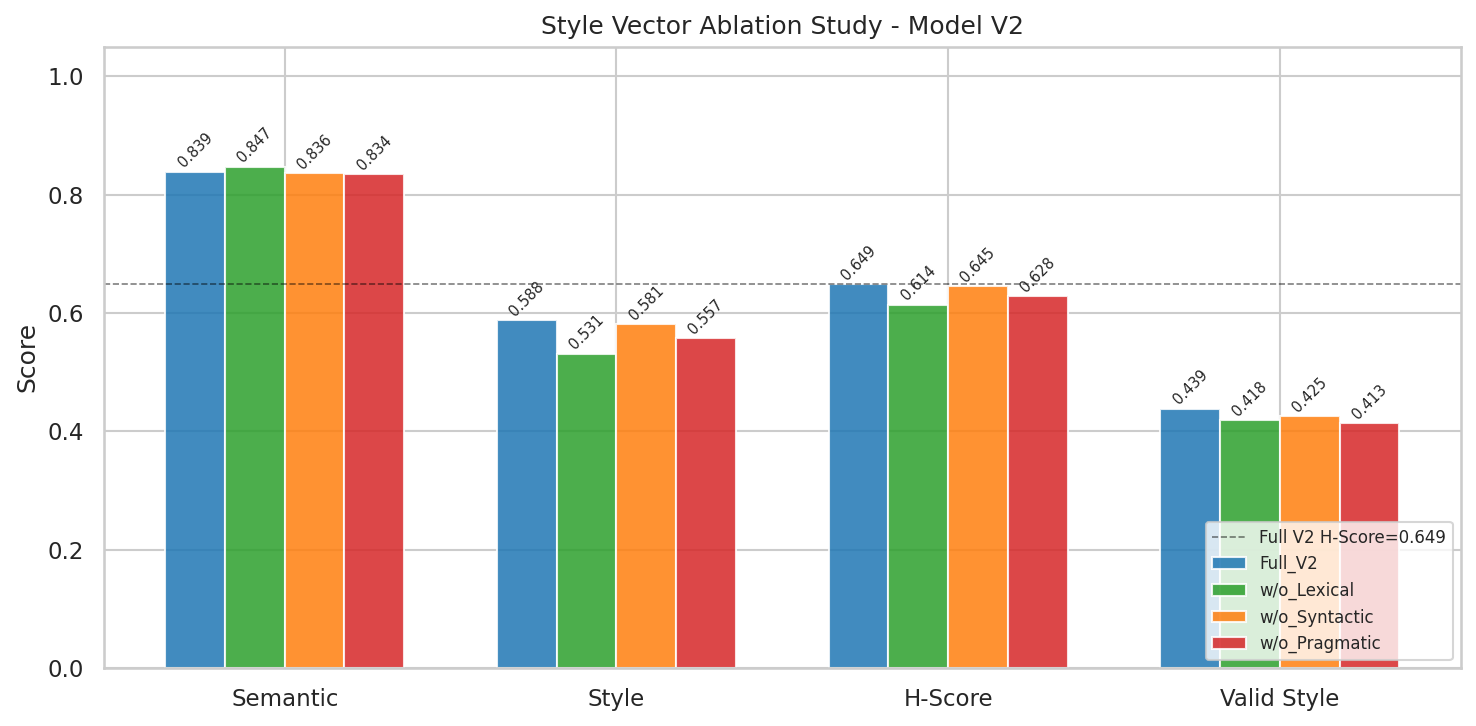

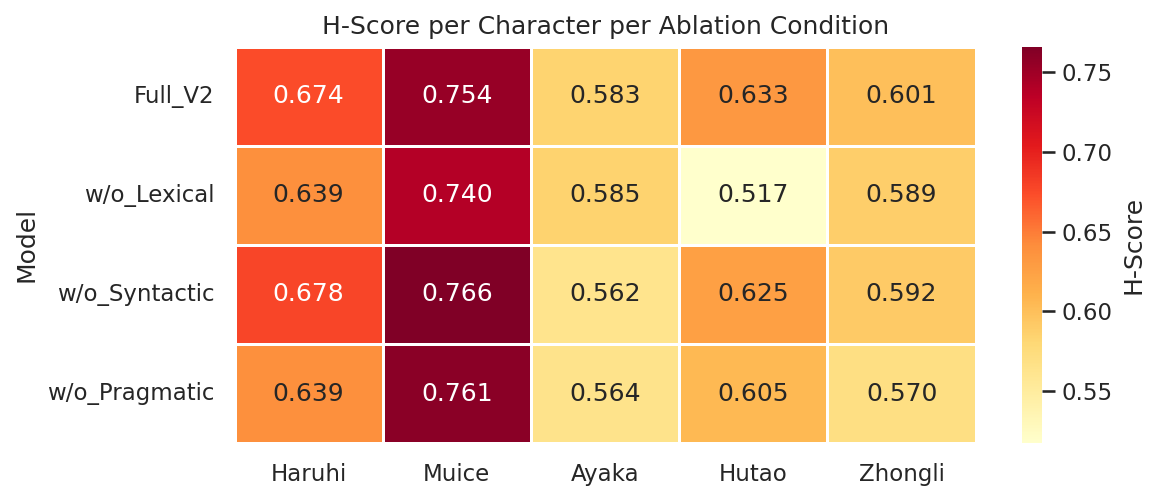


=== Final Summary Table ===


,Semantic,Style,H-Score,Valid Style
model,,,,
Full_V2,0.8387,0.5875,0.6490,0.4385
w/o_Syntactic,0.8356,0.5805,0.6447,0.4253
w/o_Pragmatic,0.8344,0.5569,0.6278,0.4135
w/o_Lexical,0.8471,0.5312,0.6138,0.4184



All figures saved to: /root/OtakuLab/outputs/ablation_style_vectors


In [ ]:
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# ── Chinese → English display name mapping (avoids CJK glyph warnings) ───────────
CHAR_EN = {
    "沐雪":    "Muice",
    "神里绫华": "Ayaka",
    "钟离":    "Zhongli",
    "胡桃":    "Hutao",
    "凉宫春日": "Haruhi",
}

# ── Reload if needed ─────────────────────────────────────────────────────────────
if "agg" not in dir():
    agg = pd.read_csv(RESULT_DIR / "eval_summary.csv", index_col=0)
    df_eval = pd.read_csv(RESULT_DIR / "eval_detailed.csv")

# ── Figure 1: Grouped bar chart across four models ───────────────────────────────
METRICS     = ["Semantic", "Style", "H-Score", "Valid Style"]
MODEL_ORDER = ["Full_V2", "w/o_Lexical", "w/o_Syntactic", "w/o_Pragmatic"]
COLORS      = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]

plot_df = agg.reindex(MODEL_ORDER)   # index = model name, columns = metric names

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
x     = np.arange(len(METRICS))
width = 0.18

for i, (model_name, color) in enumerate(zip(MODEL_ORDER, COLORS)):
    if model_name not in plot_df.index:
        continue
    # Chain .loc[row] then [cols] to avoid tuple-indexing type error
    vals: list[float] = plot_df.loc[model_name][METRICS].to_numpy(dtype=float).tolist()
    offset = (i - 1.5) * width
    bars   = ax.bar(x + offset, vals, width, label=model_name, color=color, alpha=0.85)
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.002,
                f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=7, rotation=45)

if "Full_V2" in agg.index:
    # Use list-form row label so .loc returns Series (not Scalar), then .to_numpy()
    full_h = float(agg.loc[["Full_V2"], "H-Score"].to_numpy(dtype=float)[0])
    ax.axhline(full_h, linestyle="--", color="black", linewidth=0.8, alpha=0.5,
               label=f"Full V2 H-Score={full_h:.3f}")

ax.set_xticks(x)
ax.set_xticklabels(METRICS)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Style Vector Ablation Study - Model V2")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(RESULT_DIR / "ablation_bar.pdf", bbox_inches="tight")
plt.savefig(RESULT_DIR / "ablation_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Figure 2: Per-character H-Score heatmap ──────────────────────────────────────
pivot = (
    df_eval.groupby(["model", "character"])["h_score"]
    .mean()
    .unstack("character")
    .reindex(MODEL_ORDER)
)
# Rename columns to English so no CJK font is needed
pivot.columns = [CHAR_EN.get(str(c), str(c)) for c in pivot.columns]

fig2, ax2 = plt.subplots(figsize=(8, 3.5), dpi=150)
sns.heatmap(
    pivot, ax=ax2, annot=True, fmt=".3f", cmap="YlOrRd",
    linewidths=0.5, cbar_kws={"label": "H-Score"},
)
ax2.set_title("H-Score per Character per Ablation Condition")
ax2.set_xlabel("")
ax2.set_ylabel("Model")
plt.tight_layout()
plt.savefig(RESULT_DIR / "ablation_heatmap.pdf", bbox_inches="tight")
plt.savefig(RESULT_DIR / "ablation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n=== Final Summary Table ===")
display(agg)

print(f"\nAll figures saved to: {RESULT_DIR}")
